# Week 4 Jupyter Notebook — Logistic Regression and Feature Scaling


## Objective

This notebook applies Week 4 logistic regression and feature scaling to the flight delay dataset. Since `DEP_DEL15` is a binary target, logistic regression is a better fit for the main prediction task than regular linear regression.

I compared logistic regression with and without scaling and evaluated the model using classification metrics such as accuracy, precision, recall, F1 score, ROC-AUC, and a confusion matrix.


In [18]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")


## 1. Load the datasets

The main modeling data comes from the Kaggle `train.csv` and `test.csv` files. The BTS `Flight_Delay.csv` file is used as supporting 2019 delay-cause context.

This notebook uses a sample from the Kaggle training file so it runs more easily.

In [19]:
# Load data
# Data files are stored in the data folder.

SAMPLE_SIZE = 100000
TEST_SAMPLE_SIZE = 50000
RANDOM_STATE = 42

train = pd.read_csv("data/train.csv", nrows=SAMPLE_SIZE)
test = pd.read_csv("data/test.csv", nrows=TEST_SAMPLE_SIZE)
flight_delay = pd.read_csv("data/Flight_delay.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Flight_Delay shape:", flight_delay.shape)

train.head()


Train shape: (100000, 30)
Test shape: (50000, 30)
Flight_Delay shape: (484551, 29)


,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


## 2. Quick EDA

The target variable is `DEP_DEL15`.

- `0` means the flight was not delayed by at least 15 minutes.
- `1` means the flight was delayed by at least 15 minutes.

This is why logistic regression is a better fit for Week 4. Instead of predicting a continuous number, the model predicts the probability that a flight will be delayed.

Target counts:
DEP_DEL15
0    81025
1    18975
Name: count, dtype: int64

Target percentage:
DEP_DEL15
0    81.03
1    18.98
Name: proportion, dtype: float64


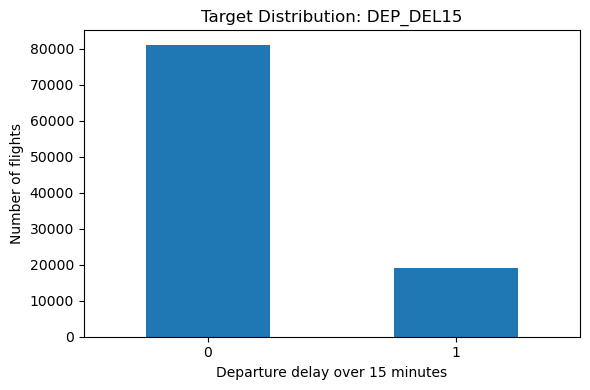


Missing values, top 10:
MONTH                 0
DAY_OF_WEEK           0
DAY_HISTORICAL        0
DEP_AIRPORT_HIST      0
CARRIER_HISTORICAL    0
AWND                  0
TMAX                  0
SNWD                  0
SNOW                  0
PRCP                  0
dtype: int64


In [20]:
target = "DEP_DEL15"

print("Target counts:")
print(train[target].value_counts(dropna=False))

print("\nTarget percentage:")
print((train[target].value_counts(normalize=True, dropna=False) * 100).round(2))

train[target].value_counts().sort_index().plot(kind="bar", figsize=(6, 4))
plt.title("Target Distribution: DEP_DEL15")
plt.xlabel("Departure delay over 15 minutes")
plt.ylabel("Number of flights")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nMissing values, top 10:")
print(train.isna().sum().sort_values(ascending=False).head(10))


BTS total delay minutes by cause:
LateAircraftDelay    12915022
CarrierDelay          8440607
NASDelay              6589613
WeatherDelay          1527927
SecurityDelay           39749
dtype: int64


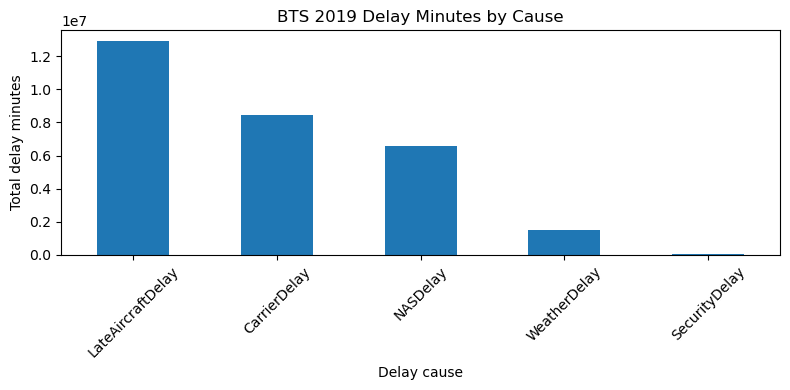

In [21]:
# BTS delay-cause context

bts_delay_cols = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

available_bts_cols = [col for col in bts_delay_cols if col in flight_delay.columns]

if available_bts_cols:
    delay_totals = flight_delay[available_bts_cols].sum().sort_values(ascending=False)

    print("BTS total delay minutes by cause:")
    print(delay_totals)

    delay_totals.plot(kind="bar", figsize=(8, 4))
    plt.title("BTS 2019 Delay Minutes by Cause")
    plt.ylabel("Total delay minutes")
    plt.xlabel("Delay cause")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("BTS delay-cause columns not found. Columns available:")
    print(flight_delay.columns.tolist())


## 3. Select features

For Week 4, I am using both numeric and categorical predictors. This is useful because departure delay risk can depend on measured values like weather and airport activity, but also on categories like airline, departure airport, and departure time block.

The categorical variables are one-hot encoded. Numeric variables are scaled for the scaled logistic regression model.

In [22]:
numeric_candidates = [
    "MONTH",
    "DAY_OF_WEEK",
    "DISTANCE_GROUP",
    "SEGMENT_NUMBER",
    "CONCURRENT_FLIGHTS",
    "NUMBER_OF_SEATS",
    "AIRPORT_FLIGHTS_MONTH",
    "AIRLINE_FLIGHTS_MONTH",
    "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT",
    "AVG_MONTHLY_PASS_AIRLINE",
    "FLT_ATTENDANTS_PER_PASS",
    "GROUND_SERV_PER_PASS",
    "PLANE_AGE",
    "LATITUDE",
    "LONGITUDE",
    "PRCP",
    "SNOW",
    "SNWD",
    "TMAX",
    "AWND",
    "CARRIER_HISTORICAL",
    "DEP_AIRPORT_HIST",
    "DAY_HISTORICAL",
    "DEP_BLOCK_HIST"
]

categorical_candidates = [
    "DEP_TIME_BLK",
    "CARRIER_NAME",
    "DEPARTING_AIRPORT"
]

numeric_features = [col for col in numeric_candidates if col in train.columns]
categorical_features = [col for col in categorical_candidates if col in train.columns]

model_data = train[numeric_features + categorical_features + [target]].dropna()

X = model_data[numeric_features + categorical_features]
y = model_data[target].astype(int)

print("Rows used:", X.shape[0])
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Categorical columns used:", categorical_features)


Rows used: 100000
Numeric features: 25
Categorical features: 3
Categorical columns used: ['DEP_TIME_BLK', 'CARRIER_NAME', 'DEPARTING_AIRPORT']


## 4. Train/test split

I use a validation split so the model is evaluated on data it did not train on. I also use `stratify=y` so the delayed and non-delayed class balance stays similar in both the training and validation sets.

In [23]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])
print("\nTraining target rate:")
print(y_train.value_counts(normalize=True).round(3))
print("\nValidation target rate:")
print(y_valid.value_counts(normalize=True).round(3))


Training rows: 75000
Validation rows: 25000

Training target rate:
DEP_DEL15
0    0.81
1    0.19
Name: proportion, dtype: float64

Validation target rate:
DEP_DEL15
0    0.81
1    0.19
Name: proportion, dtype: float64


## 5. Logistic regression without feature scaling

This first logistic regression model one-hot encodes the categorical variables but does not scale the numeric variables. This gives a comparison point for the scaled model.

Scaling matters for logistic regression because the model uses optimization. When numeric predictors are on very different scales, the optimization can be slower or less stable.

In [24]:
# Preprocessor without scaling

preprocessor_no_scaling = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", max_categories=20), categorical_features)
    ]
)

log_model_no_scaling = Pipeline([
    ("preprocessor", preprocessor_no_scaling),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

log_model_no_scaling.fit(X_train, y_train)

pred_no_scaling = log_model_no_scaling.predict(X_valid)
prob_no_scaling = log_model_no_scaling.predict_proba(X_valid)[:, 1]

print("Logistic Regression Without Scaling")
print("Accuracy:", round(accuracy_score(y_valid, pred_no_scaling), 4))
print("Precision:", round(precision_score(y_valid, pred_no_scaling), 4))
print("Recall:", round(recall_score(y_valid, pred_no_scaling), 4))
print("F1:", round(f1_score(y_valid, pred_no_scaling), 4))
print("ROC-AUC:", round(roc_auc_score(y_valid, prob_no_scaling), 4))

print("\nClassification report:")
print(classification_report(y_valid, pred_no_scaling))


Logistic Regression Without Scaling
Accuracy: 0.4519
Precision: 0.1993
Recall: 0.6256
F1: 0.3023
ROC-AUC: 0.5201

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.41      0.55     20256
           1       0.20      0.63      0.30      4744

    accuracy                           0.45     25000
   macro avg       0.51      0.52      0.43     25000
weighted avg       0.71      0.45      0.50     25000



## 6. Logistic regression with feature scaling

This model scales the numeric features before fitting logistic regression. The categorical features are still one-hot encoded.

This is usually the better setup for logistic regression because scaled features help the model treat numeric variables more evenly.

In [25]:
# Preprocessor with scaling

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", max_categories=20), categorical_features)
    ]
)

log_model_scaled = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

log_model_scaled.fit(X_train, y_train)

pred_scaled = log_model_scaled.predict(X_valid)
prob_scaled = log_model_scaled.predict_proba(X_valid)[:, 1]

print("Logistic Regression With Scaling")
print("Accuracy:", round(accuracy_score(y_valid, pred_scaled), 4))
print("Precision:", round(precision_score(y_valid, pred_scaled), 4))
print("Recall:", round(recall_score(y_valid, pred_scaled), 4))
print("F1:", round(f1_score(y_valid, pred_scaled), 4))
print("ROC-AUC:", round(roc_auc_score(y_valid, prob_scaled), 4))

print("\nClassification report:")
print(classification_report(y_valid, pred_scaled))


Logistic Regression With Scaling
Accuracy: 0.6177
Precision: 0.283
Recall: 0.6615
F1: 0.3964
ROC-AUC: 0.6866

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.61      0.72     20256
           1       0.28      0.66      0.40      4744

    accuracy                           0.62     25000
   macro avg       0.58      0.63      0.56     25000
weighted avg       0.77      0.62      0.66     25000



## 7. Compare scaled vs. unscaled logistic regression

This table compares the two logistic regression models. For this project, recall is important because missing delayed flights is a meaningful problem. Accuracy alone can be misleading if most flights are not delayed.

In [26]:
week4_results = pd.DataFrame([
    {
        "Model": "Logistic Regression Without Scaling",
        "Accuracy": accuracy_score(y_valid, pred_no_scaling),
        "Precision": precision_score(y_valid, pred_no_scaling),
        "Recall": recall_score(y_valid, pred_no_scaling),
        "F1": f1_score(y_valid, pred_no_scaling),
        "ROC-AUC": roc_auc_score(y_valid, prob_no_scaling)
    },
    {
        "Model": "Logistic Regression With Scaling",
        "Accuracy": accuracy_score(y_valid, pred_scaled),
        "Precision": precision_score(y_valid, pred_scaled),
        "Recall": recall_score(y_valid, pred_scaled),
        "F1": f1_score(y_valid, pred_scaled),
        "ROC-AUC": roc_auc_score(y_valid, prob_scaled)
    }
])

week4_results


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression Without Scaling,0.45188,0.199261,0.625632,0.302256,0.520111
1,Logistic Regression With Scaling,0.61768,0.282958,0.661467,0.396362,0.686564


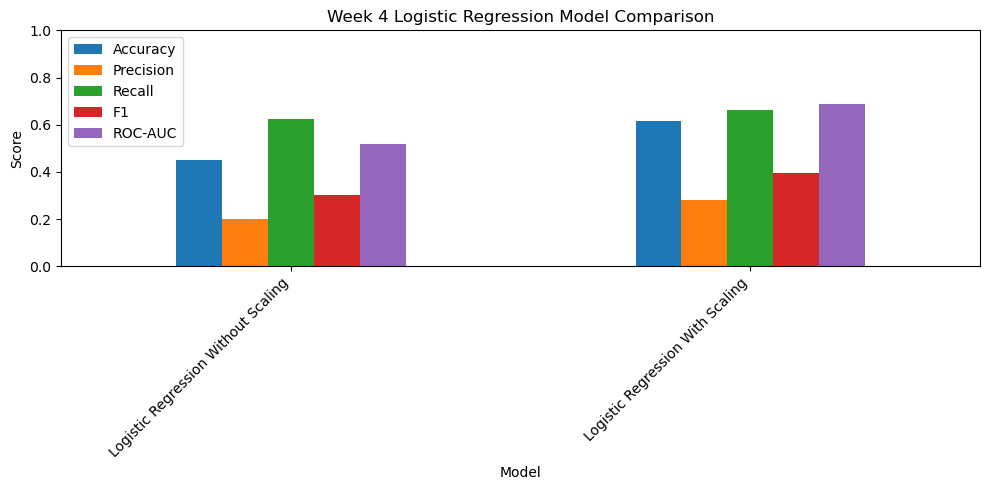

In [27]:
week4_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Week 4 Logistic Regression Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 8. Confusion matrix

The confusion matrix shows the actual counts of correct and incorrect classifications.

- True negatives: correctly predicted not delayed
- False positives: predicted delayed, but actually not delayed
- False negatives: predicted not delayed, but actually delayed
- True positives: correctly predicted delayed

For this project, false negatives matter because those are delayed flights the model missed.

In [28]:
cm = confusion_matrix(y_valid, pred_scaled)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Delayed", "Actual Delayed"],
    columns=["Predicted Not Delayed", "Predicted Delayed"]
)

cm_df


,Predicted Not Delayed,Predicted Delayed
Actual Not Delayed,12304,7952
Actual Delayed,1606,3138


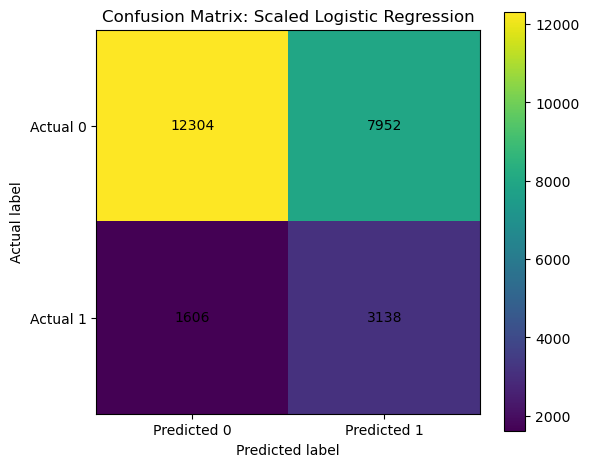

In [29]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix: Scaled Logistic Regression")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Predicted 0", "Predicted 1"])
plt.yticks(tick_marks, ["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


## 9. ROC curve

The ROC curve shows how well the model separates delayed and non-delayed flights across different probability thresholds. ROC-AUC is useful because it evaluates the ranking of predicted probabilities, not just one cutoff.

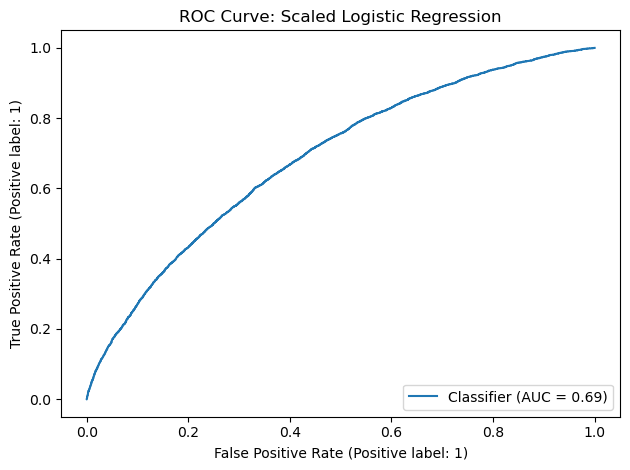

In [30]:
RocCurveDisplay.from_predictions(y_valid, prob_scaled)
plt.title("ROC Curve: Scaled Logistic Regression")
plt.tight_layout()
plt.show()


## 10. Top logistic regression coefficients

This section looks at which features have the strongest positive and negative coefficients. Positive coefficients increase the predicted probability of delay, while negative coefficients decrease it.

Because the model uses one-hot encoding, some of the feature names represent categories like airlines, airports, or departure time blocks.

In [31]:
# Get feature names from the scaled model

preprocessor = log_model_scaled.named_steps["preprocessor"]
model = log_model_scaled.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

top_positive = coef_df.sort_values("Coefficient", ascending=False).head(15)
top_negative = coef_df.sort_values("Coefficient", ascending=True).head(15)

print("Top positive coefficients:")
display(top_positive)

print("Top negative coefficients:")
display(top_negative)


Top positive coefficients:


,Feature,Coefficient
39,cat__DEP_TIME_BLK_1900-1959,0.581648
38,cat__DEP_TIME_BLK_1800-1859,0.494449
40,cat__DEP_TIME_BLK_2000-2059,0.489515
41,cat__DEP_TIME_BLK_2100-2159,0.451473
37,cat__DEP_TIME_BLK_1700-1759,0.432531
6,num__AIRPORT_FLIGHTS_MONTH,0.417973
77,cat__DEPARTING_AIRPORT_San Francisco Internati...,0.413032
36,cat__DEP_TIME_BLK_1600-1659,0.393983
48,cat__CARRIER_NAME_Atlantic Southeast Airlines,0.344003
42,cat__DEP_TIME_BLK_2200-2259,0.323134


Top negative coefficients:


,Feature,Coefficient
26,cat__DEP_TIME_BLK_0600-0659,-1.084530
25,cat__DEP_TIME_BLK_0001-0559,-0.967420
27,cat__DEP_TIME_BLK_0700-0759,-0.711459
28,cat__DEP_TIME_BLK_0800-0859,-0.467251
61,cat__DEPARTING_AIRPORT_Atlanta Municipal,-0.365944
9,num__AVG_MONTHLY_PASS_AIRPORT,-0.316460
53,cat__CARRIER_NAME_Hawaiian Airlines Inc.,-0.295669
29,cat__DEP_TIME_BLK_0900-0959,-0.261411
65,cat__DEPARTING_AIRPORT_Douglas Municipal,-0.250414
30,cat__DEP_TIME_BLK_1000-1059,-0.234557


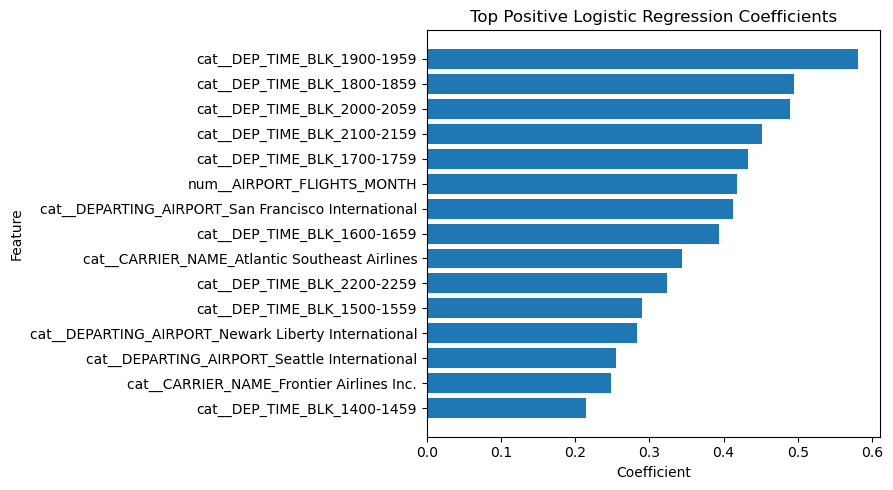

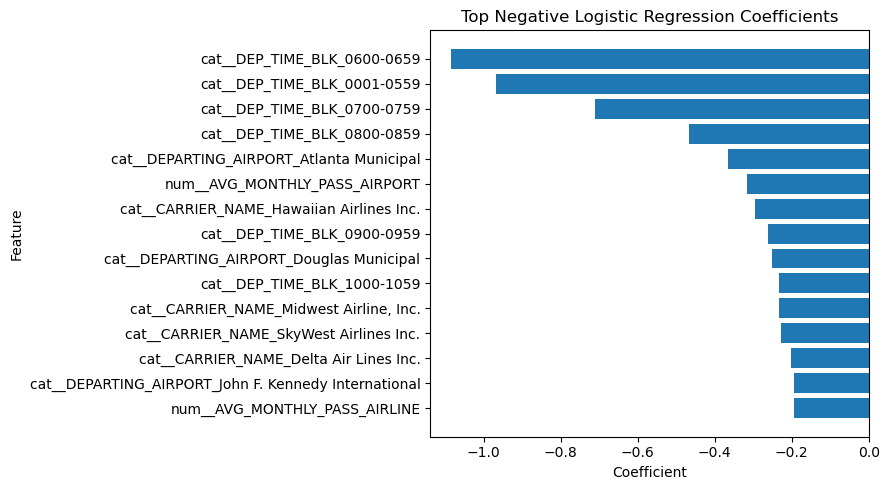

In [32]:
# Plot top positive coefficients

plt.figure(figsize=(9, 5))
plt.barh(top_positive["Feature"], top_positive["Coefficient"])
plt.title("Top Positive Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Plot top negative coefficients

plt.figure(figsize=(9, 5))
plt.barh(top_negative["Feature"], top_negative["Coefficient"])
plt.title("Top Negative Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 11. Threshold adjustment

The default logistic regression cutoff is 0.50. That means the model predicts delay only when the predicted probability is at least 50%.

For this project, it may make sense to lower the threshold if we care more about catching delayed flights. Lowering the threshold usually increases recall but decreases precision.

In [33]:
thresholds = [0.30, 0.40, 0.50, 0.60]

threshold_results = []

for threshold in thresholds:
    threshold_preds = (prob_scaled >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_valid, threshold_preds),
        "Precision": precision_score(y_valid, threshold_preds),
        "Recall": recall_score(y_valid, threshold_preds),
        "F1": f1_score(y_valid, threshold_preds)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df


,Threshold,Accuracy,Precision,Recall,F1
0,0.3,0.33000,0.213406,0.942243,0.347995
1,0.4,0.46832,0.242002,0.845067,0.376255
2,0.5,0.61768,0.282958,0.661467,0.396362
3,0.6,0.74364,0.347834,0.401138,0.372589


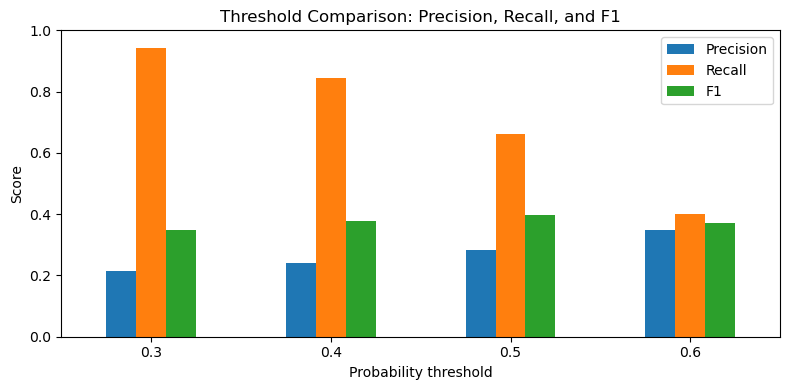

In [34]:
threshold_df.set_index("Threshold")[["Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Threshold Comparison: Precision, Recall, and F1")
plt.ylabel("Score")
plt.xlabel("Probability threshold")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Week 4 Conclusion

In this notebook, I used logistic regression because `DEP_DEL15` is a binary target that shows whether a flight was delayed by 15 minutes or more. This made classification metrics more appropriate than regression metrics for evaluating model performance.

Feature scaling made a clear difference. The scaled logistic regression model performed better than the unscaled model because the numeric predictors were placed on comparable scales before fitting the model. This helped the model use variables such as weather, distance, airport history, and carrier history more effectively.

Overall, logistic regression was a better match for the delay prediction task than treating the target as a continuous regression outcome. The results also showed that recall and F1 score are important for this project because identifying delayed flights matters more than only maximizing overall accuracy.
